In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
data_path = '../../data/1minute_data_austin/1minute_data_austin.csv'
data_raw = pd.read_csv(data_path)
data_raw['localminute'] = pd.to_datetime(data_raw['localminute'], utc=True)

In [23]:
columns = data_raw.columns
home_ids = data_raw["dataid"].unique()
num_rows = data_raw["dataid"].value_counts()

In [24]:
coverage = (
    data_raw.groupby('dataid')['localminute']
    .agg(min_ts='min', max_ts='max', actual_entries='count')
    .assign(
        time_span=lambda d: d['max_ts'] - d['min_ts'] + pd.Timedelta(minutes=1),
        time_span_minutes=lambda d: d['time_span'].dt.total_seconds() / 60,
        coverage_ratio=lambda d: d['actual_entries'] / (d['time_span'].dt.total_seconds() / 60),
    )
)
coverage

,min_ts,max_ts,actual_entries,time_span,time_span_minutes,coverage_ratio
dataid,,,,,,
661,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,525530,365 days 00:00:00,525600.0,0.999867
1642,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,519780,365 days 00:00:00,525600.0,0.988927
2335,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,517080,365 days 00:00:00,525600.0,0.983790
2361,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,524820,365 days 00:00:00,525600.0,0.998516
2818,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,524760,365 days 00:00:00,525600.0,0.998402
3039,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,525596,365 days 00:00:00,525600.0,0.999992
3456,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,524040,365 days 00:00:00,525600.0,0.997032
3538,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,525600,365 days 00:00:00,525600.0,1.000000
4031,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,525600,365 days 00:00:00,525600.0,1.000000


In [25]:
feature_cols = [c for c in data_raw.columns if c not in ('dataid', 'localminute')]
fill_pct = (
    data_raw.groupby('dataid')[feature_cols]
    .apply(lambda g: g.notna().mean() * 100)
)
cols_to_keep = fill_pct.columns[(fill_pct > 0).any(axis=0)]
fill_pct = fill_pct[cols_to_keep]
fill_pct

,air1,air2,airwindowunit1,bathroom1,bathroom2,bedroom1,bedroom2,bedroom3,car1,clotheswasher1,...,refrigerator2,solar,sprinkler1,utilityroom1,venthood1,waterheater1,waterheater2,winecooler1,leg1v,leg2v
dataid,,,,,,,,,,,,,,,,,,,,,
661,99.052385,0.000000,0.0,91.531216,0.000000,0.000000,0.000000,0.000000,99.052385,91.531216,...,0.000000,99.052385,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,98.972466,98.972466
1642,99.480549,0.000000,0.0,96.616838,0.000000,0.000000,0.000000,0.000000,99.480549,96.616838,...,0.000000,99.480549,0.0,96.616838,96.616838,0.000000,0.000000,0.000000,99.388203,99.388203
2335,99.996519,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,99.988396,99.907171,...,0.000000,99.996519,0.0,0.000000,99.988396,0.000000,0.000000,0.000000,99.915294,99.915294
2361,100.000000,0.000000,0.0,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.908540,...,0.000000,100.000000,0.0,0.000000,100.000000,0.000000,0.000000,0.000000,99.908540,99.908540
2818,100.000000,0.000000,0.0,99.908530,0.000000,99.908530,0.000000,0.000000,0.000000,100.000000,...,0.000000,100.000000,100.0,0.000000,100.000000,0.000000,0.000000,0.000000,99.908530,99.908530
3039,98.504555,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,91.792936,...,0.000000,98.504555,0.0,0.000000,0.000000,91.872084,91.872084,91.872084,98.436822,98.436822
3456,99.988550,0.000000,0.0,100.000000,0.000000,100.000000,0.000000,0.000000,0.000000,99.908404,...,0.000000,99.988550,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,99.896954,99.896954
3538,100.000000,0.000000,0.0,99.908676,0.000000,99.988584,0.000000,0.000000,0.000000,99.988584,...,0.000000,100.000000,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,99.920091,99.920091
4031,0.000000,0.000000,0.0,0.000000,0.000000,99.920091,0.000000,0.000000,0.000000,99.920091,...,0.000000,99.988584,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,99.908676,99.908676


In [26]:
(fill_pct > 0).sum().sort_values(ascending = False)

leg2v                   25
leg1v                   25
grid                    25
dishwasher1             25
clotheswasher1          24
furnace1                24
air1                    24
refrigerator1           23
microwave1              22
solar                   20
kitchenapp1             20
drye1                   18
kitchenapp2             16
oven1                   16
disposal1               15
lights_plugs1           12
bedroom1                11
bathroom1               11
dryg1                   10
livingroom1              9
car1                     9
lights_plugs2            9
venthood1                7
lights_plugs3            5
kitchen1                 4
office1                  4
bedroom2                 4
garage1                  3
furnace2                 3
range1                   3
air2                     2
refrigerator2            2
waterheater1             2
utilityroom1             2
sprinkler1               2
diningroom1              2
freezer1                 2
o

In [51]:
def get_single_home(homeid): 
    df_home = data_raw.loc[data_raw["dataid"] == homeid]
    df_home = df_home.drop(columns = ["dataid", "leg1v", "leg2v"])
    df_home = df_home.dropna(axis=1, how="all")
    df_home = df_home.set_index("localminute")
    df_home.index = pd.to_datetime(df_home.index, utc = True)
    return df_home

In [52]:
df_home = get_single_home(1642)
df_home_hourly = df_home.resample('h').mean()

Text(0.5, 1.0, 'Power Heatmap')

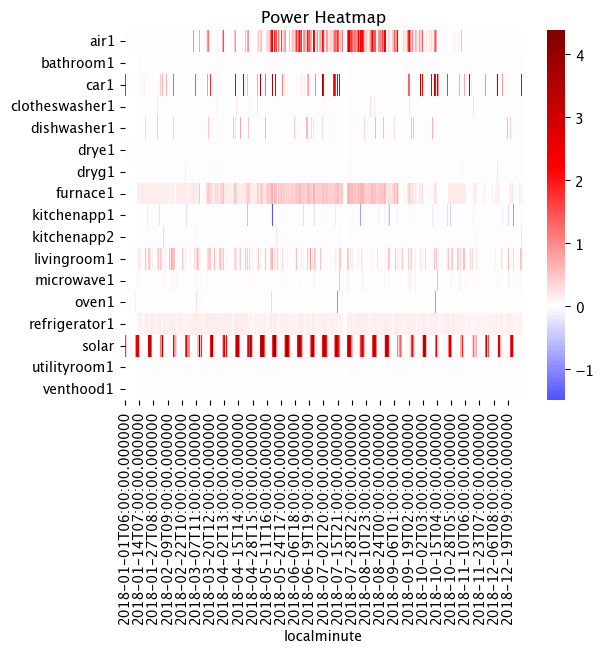

In [53]:
sns.heatmap(data = df_home_hourly.drop(columns = "grid").T, cmap = "seismic", center = 0)
plt.title("Power Heatmap")

<Axes: xlabel='localminute'>

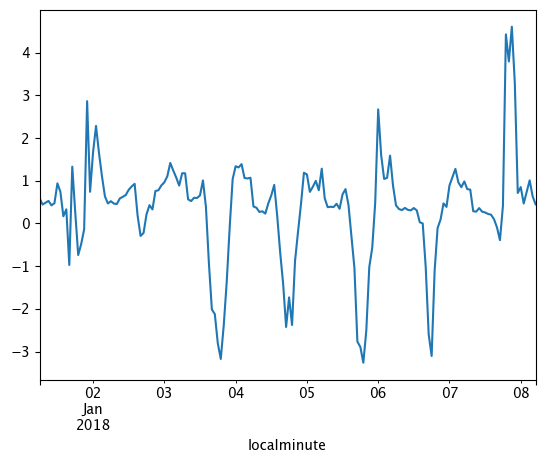

In [49]:
df_home_hourly["grid"][:7*24].plot()

In [32]:
ev_daily = df_home_hourly.pivot(
    index=df_home_hourly.index.time,
    columns=df_home_hourly.index.date,
    values="car1"
)

KeyError: datetime.time(6, 0)

In [34]:
tmp = df_home_hourly.assign(
    day=df_home_hourly.index.date,
    time=df_home_hourly.index.time,
)
ev_daily = tmp.pivot_table(index="time", columns="day", values="car1")

In [46]:
weekly = (
    df_home_hourly
    .assign(
        hour=lambda x: x.index.hour,
        week=lambda x: x.index.to_period("W")  # week periods
    )
    .pivot_table(index="hour", columns="week", values="car1")
)

/var/folders/0h/cpmzljqs7y98z5g9zx33_kmc0000gn/T/ipykernel_29390/1200779291.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  week=lambda x: x.index.to_period("W")  # week periods


In [43]:
ev_daily.

day,2018-01-01,2018-01-02,2018-01-03,2018-01-04,2018-01-05,2018-01-06,2018-01-07,2018-01-08,2018-01-09,2018-01-10,...,2018-12-23,2018-12-24,2018-12-25,2018-12-26,2018-12-27,2018-12-28,2018-12-29,2018-12-30,2018-12-31,2019-01-01
time,,,,,,,,,,,,,,,,,,,,,
00:00:00,NaN,0.062133,-0.001817,-0.003033,-0.002000,-0.005750,-0.001317,-0.000667,-0.000133,-0.002667,...,0.001000,0.413250,-0.000700,0.000633,0.000417,-0.000050,0.000433,-0.001267,0.978533,0.250650
01:00:00,NaN,0.055317,-0.002100,-0.001583,-0.000283,-0.002650,-0.001883,0.001000,-0.001633,-0.000250,...,0.001000,0.000567,-0.000250,0.000350,0.000567,-0.000467,0.001667,0.000850,-0.001217,0.000517
02:00:00,NaN,0.383900,-0.003867,-0.003150,-0.001150,-0.001267,-0.002400,0.000083,-0.001450,-0.001050,...,2.687483,-0.000100,0.001033,-0.000417,0.000883,0.000033,0.001033,0.001000,0.000400,0.000833
03:00:00,NaN,0.002017,-0.002983,-0.001500,-0.002183,-0.001017,-0.001083,-0.001267,0.000683,-0.000933,...,3.376117,-0.000350,0.001133,0.000300,0.000917,0.000583,0.000000,0.001000,-0.000150,0.000850
04:00:00,NaN,0.014683,-0.001650,-0.000050,-0.000850,-0.002083,-0.000733,-0.000100,-0.000800,0.000983,...,3.375100,-0.000850,0.001400,0.001000,-0.000317,0.001933,0.000850,0.001000,0.000350,0.000800
05:00:00,NaN,0.068817,-0.001183,-0.000333,-0.000600,-0.000867,-0.001650,0.000950,0.000400,0.000600,...,1.362750,-0.000500,0.001833,0.001133,0.000917,0.001883,0.001667,3.039833,0.001000,0.000967
06:00:00,0.001017,0.058150,-0.000567,0.000950,0.000900,0.000783,0.000550,0.000967,0.001000,0.000350,...,0.001067,0.000267,0.001750,0.001800,0.001283,0.001983,0.001967,3.370467,0.001000,NaN
07:00:00,0.001017,0.056517,0.000150,0.000917,0.000917,0.001000,0.000567,0.001000,0.000783,0.001033,...,0.001000,0.000117,0.001850,0.001483,0.001817,0.002000,0.001917,2.446200,0.000883,NaN
08:00:00,0.001283,0.049200,0.000867,0.001417,0.000800,0.001000,0.001000,0.001617,0.001500,0.001000,...,0.001000,0.001000,0.001683,0.001767,0.001917,0.001300,0.002000,0.001700,0.000983,NaN


In [44]:
qs = np.arange(0.1, 1.0, 0.1)  # 0.1, 0.2, ..., 0.9
deciles = (
    ev_daily
    .quantile(qs, axis=1)
    .T
)
deciles.columns = [f"q{int(q*100)}" for q in qs]

<Axes: xlabel='time'>

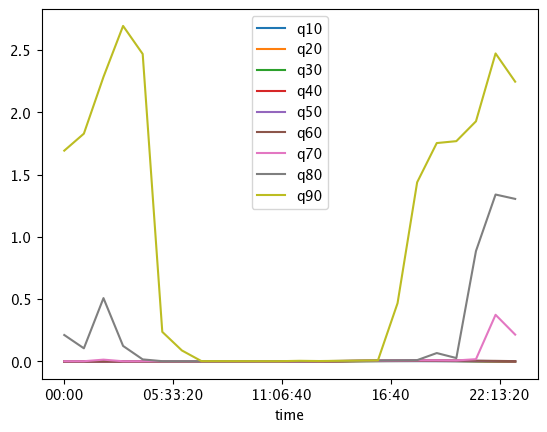

In [45]:
deciles.plot()